# Import Libirary

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

# Reading Dataset

In [ ]:
df = pd.read_csv(r'/content/synthetic_customer_behavior_and_churn.csv')
df.head()

,customer_id,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,...,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn
0,CUST_000001,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,...,55.3,12,1,5,Credit Card,monthly,4,no,yes,0
1,CUST_000002,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,...,25.7,18,1,3,Bank Transfer,yearly,13,no,yes,0
2,CUST_000003,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,...,9.0,8,6,5,Digital Wallet,monthly,54,no,yes,1
3,CUST_000004,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,...,99.4,30,1,3,Credit Card,monthly,6,no,no,0
4,CUST_000005,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,...,8.4,8,3,5,Digital Wallet,yearly,59,no,yes,0




# Data Exploration

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   15000 non-null  object 
 1   signup_date                   15000 non-null  object 
 2   tenure_months                 15000 non-null  int64  
 3   age                           15000 non-null  int64  
 4   gender                        15000 non-null  object 
 5   region                        15000 non-null  object 
 6   income_level                  15000 non-null  object 
 7   subscription_type             15000 non-null  object 
 8   monthly_charges               15000 non-null  float64
 9   total_charges                 15000 non-null  float64
 10  usage_frequency               15000 non-null  object 
 11  avg_session_duration_minutes  15000 non-null  float64
 12  number_of_logins_per_month    15000 non-null  int64  
 13  n

In [ ]:
df.describe()

,tenure_months,age,monthly_charges,total_charges,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,last_login_days_ago,churn
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000
mean,17.448467,41.646933,59.046174,978.208528,45.235633,18.519600,2.927133,3.38440,21.748533,0.318867
std,10.304214,11.740994,32.996490,864.474724,29.244734,12.335911,2.609012,1.24951,22.282570,0.466053
min,1.000000,18.000000,19.990000,16.500000,5.000000,1.000000,0.000000,1.00000,0.000000,0.000000
25%,8.000000,33.000000,31.640000,351.145000,21.900000,9.000000,1.000000,3.00000,5.000000,0.000000
50%,17.000000,42.000000,55.150000,735.260000,40.500000,16.000000,2.000000,4.00000,13.000000,0.000000
75%,26.000000,50.000000,73.742500,1372.332500,58.500000,24.000000,4.000000,4.00000,32.000000,1.000000
max,35.000000,80.000000,149.950000,5506.350000,119.900000,49.000000,11.000000,5.00000,89.000000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
customer_id,0
signup_date,0
tenure_months,0
age,0
gender,0
region,0
income_level,0
subscription_type,0
monthly_charges,0
total_charges,0


In [ ]:
df.drop('customer_id', axis=1 , inplace= True)
df.head()

,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn
0,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,medium,55.3,12,1,5,Credit Card,monthly,4,no,yes,0
1,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,medium,25.7,18,1,3,Bank Transfer,yearly,13,no,yes,0
2,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,9.0,8,6,5,Digital Wallet,monthly,54,no,yes,1
3,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,99.4,30,1,3,Credit Card,monthly,6,no,no,0
4,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,8.4,8,3,5,Digital Wallet,yearly,59,no,yes,0


In [ ]:
df['signup_date'] = pd.to_datetime(df['signup_date']) # converting data type from object to datetime
df.head()

,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn
0,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,medium,55.3,12,1,5,Credit Card,monthly,4,no,yes,0
1,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,medium,25.7,18,1,3,Bank Transfer,yearly,13,no,yes,0
2,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,9.0,8,6,5,Digital Wallet,monthly,54,no,yes,1
3,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,99.4,30,1,3,Credit Card,monthly,6,no,no,0
4,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,8.4,8,3,5,Digital Wallet,yearly,59,no,yes,0


# Feature Engineering

In [ ]:
df['signup_month'] = df['signup_date'].dt.month # extracting month from date
df.head()

,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,...,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn,signup_month
0,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,medium,...,12,1,5,Credit Card,monthly,4,no,yes,0,8
1,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,medium,...,18,1,3,Bank Transfer,yearly,13,no,yes,0,2
2,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,...,8,6,5,Digital Wallet,monthly,54,no,yes,1,7
3,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,...,30,1,3,Credit Card,monthly,6,no,no,0,5
4,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,...,8,3,5,Digital Wallet,yearly,59,no,yes,0,4


In [ ]:
df['signup_day'] = df['signup_date'].dt.day # extracting day from date
df.head()

,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,...,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn,signup_month,signup_day
0,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,medium,...,1,5,Credit Card,monthly,4,no,yes,0,8,17
1,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,medium,...,1,3,Bank Transfer,yearly,13,no,yes,0,2,21
2,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,...,6,5,Digital Wallet,monthly,54,no,yes,1,7,18
3,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,...,1,3,Credit Card,monthly,6,no,no,0,5,17
4,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,...,3,5,Digital Wallet,yearly,59,no,yes,0,4,3


In [ ]:
df['signup_year'] = df['signup_date'].dt.year # extracting year from date
df.head()

,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,...,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn,signup_month,signup_day,signup_year
0,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,medium,...,5,Credit Card,monthly,4,no,yes,0,8,17,2022
1,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,medium,...,3,Bank Transfer,yearly,13,no,yes,0,2,21,2022
2,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,...,5,Digital Wallet,monthly,54,no,yes,1,7,18,2023
3,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,...,3,Credit Card,monthly,6,no,no,0,5,17,2023
4,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,...,5,Digital Wallet,yearly,59,no,yes,0,4,3,2023


In [ ]:
df.drop('signup_date', axis=1 , inplace= True)
df.head()

,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,avg_session_duration_minutes,...,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn,signup_month,signup_day,signup_year
0,28,47,Male,North America,low,basic,35.22,1034.06,medium,55.3,...,5,Credit Card,monthly,4,no,yes,0,8,17,2022
1,34,40,Male,Europe,low,standard,63.56,2065.11,medium,25.7,...,3,Bank Transfer,yearly,13,no,yes,0,2,21,2022
2,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,9.0,...,5,Digital Wallet,monthly,54,no,yes,1,7,18,2023
3,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,99.4,...,3,Credit Card,monthly,6,no,no,0,5,17,2023
4,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,8.4,...,5,Digital Wallet,yearly,59,no,yes,0,4,3,2023


In [ ]:
df['total_support_tickets'] = df['number_of_support_tickets']/(df['tenure_months']+1)*100 #persentage of using support tickets
df.head()

,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,avg_session_duration_minutes,...,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn,signup_month,signup_day,signup_year,total_support_tickets
0,28,47,Male,North America,low,basic,35.22,1034.06,medium,55.3,...,Credit Card,monthly,4,no,yes,0,8,17,2022,3.448276
1,34,40,Male,Europe,low,standard,63.56,2065.11,medium,25.7,...,Bank Transfer,yearly,13,no,yes,0,2,21,2022,2.857143
2,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,low,9.0,...,Digital Wallet,monthly,54,no,yes,1,7,18,2023,33.333333
3,19,60,Female,Latin America,medium,premium,98.28,1540.50,high,99.4,...,Credit Card,monthly,6,no,no,0,5,17,2023,5.000000
4,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,low,8.4,...,Digital Wallet,yearly,59,no,yes,0,4,3,2023,14.285714


## Exploratory Data Analysis (EDA)

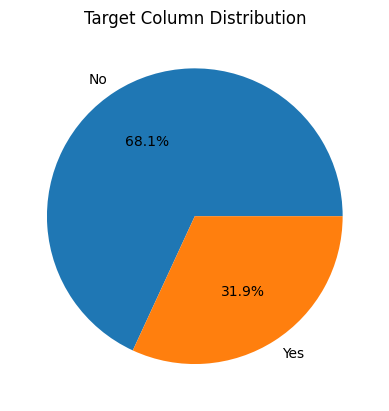

In [ ]:
## target column distributrion
plt.pie(df['churn'].value_counts(), labels=['No', 'Yes'], autopct='%1.1f%%')
plt.title('Target Column Distribution')
plt.show()

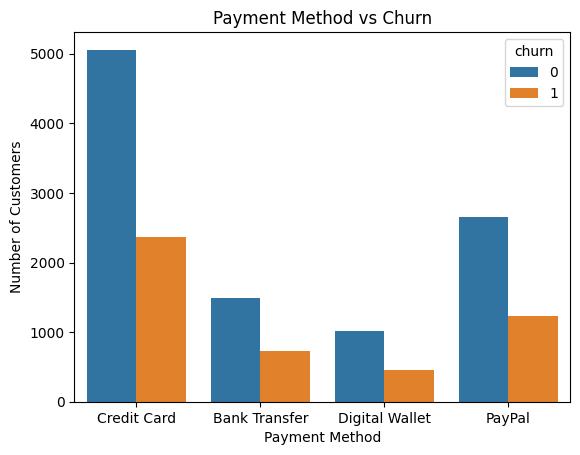

In [ ]:
## the relationship between payment method and churn
sns.countplot(x='payment_method', hue='churn', data=df)
plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.show()

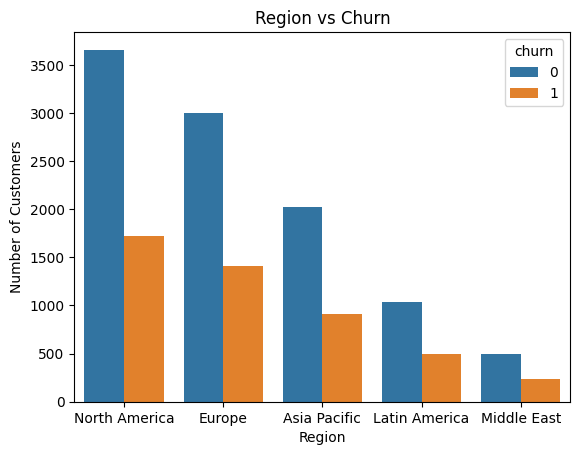

In [ ]:
## the ralationship between region and churn
sns.countplot(x='region', hue='churn', data=df)
plt.title("Region vs Churn")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.show()

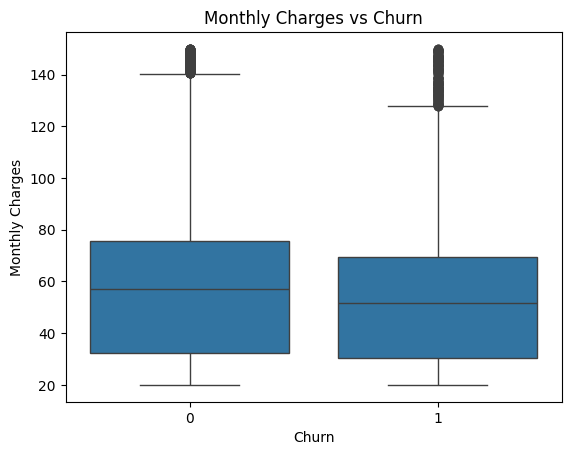

In [ ]:
## monthly charges boxplot
sns.boxplot(x='churn', y='monthly_charges', data=df)
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

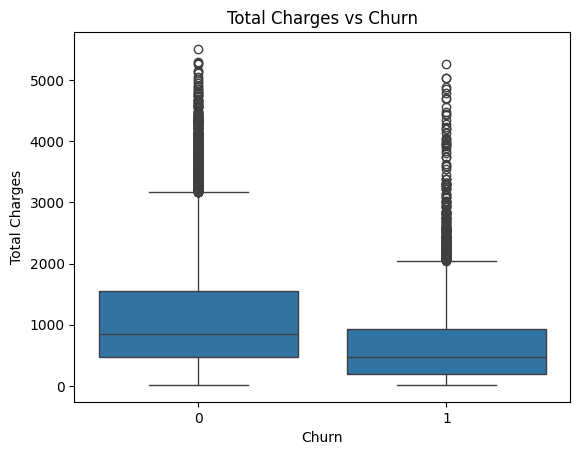

In [ ]:
## total charges boxplot
sns.boxplot(x='churn', y='total_charges', data=df)
plt.title("Total Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

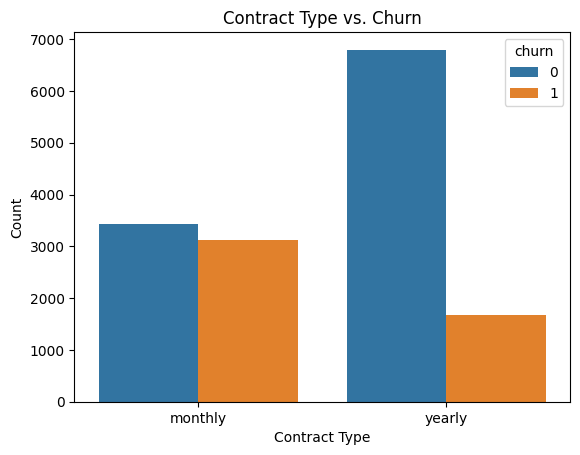

In [ ]:
## Monthly contract vs. Yearly contract in churn
sns.countplot(x='contract_type', hue='churn', data=df)
plt.title("Contract Type vs. Churn")
plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.show()

 ## Train Test Split

In [ ]:
x=df.drop('churn',axis=1)
y=df['churn']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=.8,random_state=42)

## Data Preprocessing

In [ ]:
# encoding categorical columns
encoding=OrdinalEncoder()
ordinal_cols = ['income_level','usage_frequency','contract_type']
ordinal_categories = [['low', 'medium', 'high'],['low', 'medium', 'high'],['monthly', 'yearly']]
ordinal_encoder = OrdinalEncoder(categories=ordinal_categories)
x_train[ordinal_cols] = ordinal_encoder.fit_transform(x_train[ordinal_cols])
x_test[ordinal_cols] = ordinal_encoder.transform(x_test[ordinal_cols])

cat_cols=['gender','region','subscription_type','payment_method','promotional_response','discount_used']
x_train[cat_cols]=encoding.fit_transform(x_train[cat_cols])
x_test[cat_cols]=encoding.transform(x_test[cat_cols])



In [ ]:
# new encoded dataframe
final_df = pd.concat([x_train, y_train], axis=1)

In [ ]:
final_df

,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,usage_frequency,avg_session_duration_minutes,...,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,signup_month,signup_day,signup_year,total_support_tickets,churn
9839,35,27,1.0,4.0,1.0,2.0,54.53,1993.56,0.0,10.6,...,0.0,1.0,41,0.0,1.0,1,9,2022,2.777778,0
9680,28,37,1.0,1.0,0.0,0.0,29.70,689.07,0.0,21.1,...,1.0,0.0,57,0.0,0.0,8,10,2022,3.448276,0
7093,13,56,0.0,4.0,1.0,0.0,23.46,261.08,0.0,5.6,...,1.0,0.0,13,1.0,0.0,12,1,2023,14.285714,0
11293,17,64,1.0,2.0,0.0,2.0,69.03,1079.25,0.0,12.0,...,1.0,1.0,47,1.0,0.0,7,16,2023,50.000000,1
820,29,35,1.0,1.0,2.0,2.0,50.50,1293.39,1.0,59.3,...,2.0,1.0,75,1.0,0.0,7,10,2022,16.666667,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5191,1,41,0.0,4.0,1.0,2.0,50.58,41.74,0.0,5.1,...,3.0,0.0,66,1.0,1.0,12,8,2024,500.000000,1
13418,31,43,0.0,2.0,0.0,2.0,58.27,1811.15,1.0,23.1,...,3.0,1.0,7,0.0,0.0,5,14,2022,9.375000,0
5390,33,33,1.0,1.0,1.0,0.0,34.18,955.16,1.0,59.1,...,3.0,0.0,10,0.0,1.0,3,16,2022,5.882353,0
860,10,44,1.0,4.0,1.0,2.0,59.17,524.80,1.0,27.8,...,3.0,1.0,10,0.0,1.0,2,24,2024,9.090909,0


## Data Modeling

In [ ]:
# random forest model
model = RandomForestClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy_train = accuracy_score(y_train, model.predict(x_train))
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy Train:", accuracy_train)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_rep)


Accuracy: 0.929
Accuracy Train: 1.0
Precision: 0.9235159817351598
Recall: 0.8471204188481676
F1 Score: 0.8836701256144184
Confusion Matrix:
 [[1978   67]
 [ 146  809]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      2045
           1       0.92      0.85      0.88       955

    accuracy                           0.93      3000
   macro avg       0.93      0.91      0.92      3000
weighted avg       0.93      0.93      0.93      3000



In [ ]:
# gridsearch for best Parameter
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
        }
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
grid_search.fit(x_train, y_train)
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
print("Best Parameters:", best_params)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_rep)

